# PCA (Covariance Eigendecomposition) Foreground Removal + Wiener Filter


1. Estimate the empirical sky covariance $\hat C(\ell)$ per $\ell$-bin from the masked maps.
2. **PCA via eigendecomposition**: eigendecompose the (bin-averaged) covariance, keep the top-`r`
   eigenvectors as the foreground mixing matrix $F$, and project each bin's covariance  to get $P_b(\ell) = F^\top \hat C(\ell) F$. The rank-`r` foreground model is then
   $R_{fg}(\ell) = F P_b(\ell) F^\top$.
3. **Subtract**: $\hat C_{HI+N}(\ell) = \hat C(\ell) - R_{fg}(\ell)$ 
4. **Wiener filter**: $W(\ell) = \hat C_{HI+N}(\ell)\,\hat C(\ell)^{-1}$, applied per-$\ell$ to the
   observed-data alms to debia and reconstruct clean HI+noise maps.


In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import pymaster as nmt
import sys
sys.path.append('../')

from scripts.compute_covariance import compute_covariance
from scripts.mask_maps import mask_maps

input_path = "/datadec/cppm/shoaib/SMICA_Paper/data"

In [2]:
nside = 256
npix = hp.nside2npix(nside)
freqs = np.arange(1042, 1183, step=1)  # MHz
nfreqs = len(freqs) - 1
lmax = 3 * nside - 1
ells = np.arange(2, lmax + 1)
almsize = hp.Alm.getsize(lmax)

r = 3            # foreground model rank (PCA components to remove)
bin_width = 10   # ell bin width for pseudo-Cl binning

## Helper functions

In [3]:
def apply_mask_with_nan(data, mask):
    """Apply mask to data, setting masked regions (mask==0) to NaN for better visualization."""
    masked_data = data * mask
    masked_data[mask == 0] = np.nan
    return masked_data


def bin_spectra(cl, nside, delta):
    b = nmt.NmtBin.from_nside_linear(nside, nlb=delta)
    nbins = b.get_n_bands()
    leff = b.get_effective_ells()
    cl_binned = np.zeros((nbins, nfreqs, nfreqs))
    for i in range(nfreqs):
        for j in range(nfreqs):
            cl_binned[:, i, j] = b.bin_cell(cl[:, i, j])
    return leff, nbins, cl_binned


def normalize_covariance_by_sky_fraction(mask, fgds_cl, hi_cl, noise_cl, sky_cl):
    """Normalize covariance matrices by the sky fraction."""
    fsky = mask.mean()
    pseudo_fgds_cl = fgds_cl / fsky
    pseudo_hi_cl = hi_cl / fsky
    pseudo_noise_cl = noise_cl / fsky
    pseudo_sky_cl = sky_cl / fsky
    return fsky, pseudo_fgds_cl, pseudo_hi_cl, pseudo_noise_cl, pseudo_sky_cl


def pca_init(empirical, rank):
    """Rank-`r` foreground model (F, P_b) from the top eigenvectors of the mean covariance.

    Parameters
    ----------
    empirical : np.ndarray, shape (n_bins, n_freq, n_freq)
        Per-bin empirical covariance.
    rank : int
        Number of principal components to retain.

    Returns
    -------
    F : np.ndarray, shape (n_freq, rank)
        Frequency-space eigenvectors (mixing matrix).
    P_b : np.ndarray, shape (n_bins, rank, rank)
        Per-bin covariance projected onto the F subspace.
    """
    R_global = np.mean(empirical, axis=0)

    eigvals, eigvecs = np.linalg.eigh(R_global)  # ascending order
    F_i = eigvecs[:, -rank:]  # top-`rank` eigenvectors
    P_b_i = np.zeros((empirical.shape[0], rank, rank))
    for b in range(empirical.shape[0]):
        proj = F_i.T @ empirical[b] @ F_i
        P_b_i[b] = 0.5 * (proj + proj.T)
    return F_i, P_b_i


def is_psd(mats, tol=1e-6):
    """PSD check with a small absolute tolerance -- eigh residuals of order 1e-9 to 1e-13
    """
    return all(np.all(np.linalg.eigvalsh(m) >= -tol) for m in mats)


def psd_clip(cov_binned, floor_rcond=0.0):
    """Symmetrize + floor eigenvalues, per ell bin.

    `floor_rcond` floors each bin's eigenvalues at `floor_rcond * max_eigenvalue` (relative to
    that bin's own largest eigenvalue), capping the condition number at `1 / floor_rcond`.
    `floor_rcond=0` just zeros out negative eigenvalues (plain PSD projection).
    """
    n_bins = cov_binned.shape[0]
    out = np.zeros_like(cov_binned)
    for b in range(n_bins):
        cov = 0.5 * (cov_binned[b] + cov_binned[b].T)
        eigvals, eigvecs = np.linalg.eigh(cov)
        floor = floor_rcond * eigvals.max() if floor_rcond > 0 else 0.0
        eigvals = np.clip(eigvals, a_min=floor, a_max=None)
        out[b] = eigvecs @ np.diag(eigvals) @ eigvecs.T
    return out

## Mask

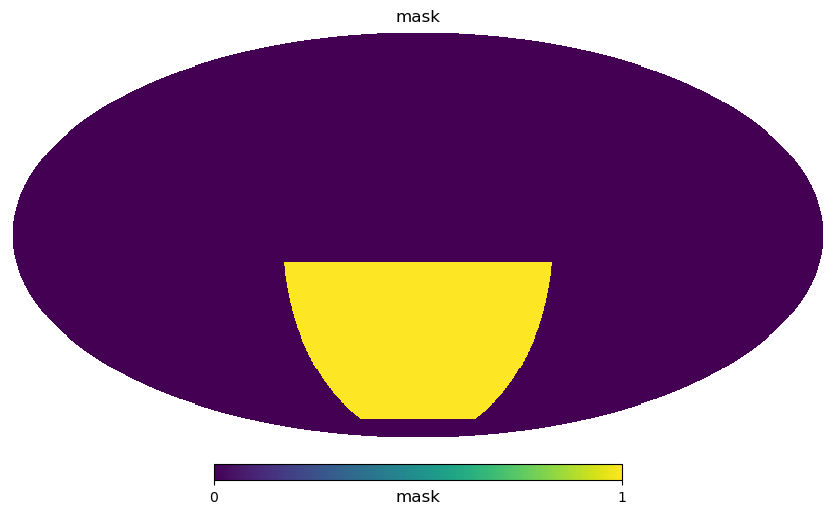

In [4]:
def create_sky_patch_mask(nside, ra_min, ra_max, dec_min, dec_max):
    """Create a rectangular sky patch mask in HEALPix format."""
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix), lonlat=False)
    ra = np.degrees(phi)
    dec = 90.0 - np.degrees(theta)
    ra = ((ra + 180) % 360) - 180
    mask = (
        (ra >= ra_min) & (ra <= ra_max) &
        (dec >= dec_min) & (dec <= dec_max)
    ).astype(np.uint8)
    return mask


mask = create_sky_patch_mask(nside=256, ra_min=-60.0, ra_max=60.0, dec_min=-75.0, dec_max=-10.0)
hp.mollview(mask, title="mask", unit="mask")

lonra, latra = [-60, 60], [-75, -10]  # patch bounds, matches create_sky_patch_mask above

## Load simulated maps
Using the same cached, alm-rotated 1042-1183 MHz maps as `SMICA.ipynb`.

In [5]:
rotated_fgds = np.load(f"{input_path}/UHF/rotated_fgds_1042_1183.npy")
rotated_hi = np.load(f"{input_path}/UHF/rotated_hi_1042_1183.npy")
rotated_noise = np.load(f"{input_path}/UHF/rotated_noise_1042_1183.npy")
rotated_sky = np.load(f"{input_path}/UHF/rotated_sky_1042_1183.npy")
"1042 - 1183MHz maps"

'1042 - 1183MHz maps'

## Mask maps and compute covariances

In [6]:
fgds_masked, _ = mask_maps(rotated_fgds, mask, almsize, lmax, nfreqs, npix)
hi_masked, _ = mask_maps(rotated_hi, mask, almsize, lmax, nfreqs, npix)
noise_masked, _ = mask_maps(rotated_noise, mask, almsize, lmax, nfreqs, npix)
sky_masked, sky_alm = mask_maps(rotated_sky, mask, almsize, lmax, nfreqs, npix)

In [7]:
fgds_cl = compute_covariance(fgds_masked, lmax, almsize, nfreqs)
hi_cl_masked = compute_covariance(hi_masked, lmax, almsize, nfreqs)
noise_cl = compute_covariance(noise_masked, lmax, almsize, nfreqs)
sky_cl = compute_covariance(sky_masked, lmax, almsize, nfreqs)
fsky, pseudo_fgds_cl, pseudo_hi_cl, pseudo_noise_cl, pseudo_sky_cl = normalize_covariance_by_sky_fraction(
    mask, fgds_cl, hi_cl_masked, noise_cl, sky_cl
)

## Bin into ell bins

In [8]:
leff, n_bins, fgds_binned = bin_spectra(pseudo_fgds_cl, nside, bin_width)
*_, hi_binned = bin_spectra(pseudo_hi_cl, nside, bin_width)
*_, noise_binned = bin_spectra(pseudo_noise_cl, nside, bin_width)
*_, sky_binned = bin_spectra(pseudo_sky_cl, nside, bin_width)

hi_noise_binned = hi_binned + noise_binned  # truth, for validation only -- never used in the model below

## PSD-clip + regularize the empirical (sky) covariance

Two problems with the raw per-bin empirical covariance $\hat C(\ell)$:

1. Pseudo-$C_\ell$ mode-coupling / binning noise can introduce small negative eigenvalues.
2. Far more importantly: there are `nfreqs` (140) frequency channels but, especially at low
   $\ell$, only a handful of independent $(\ell, m)$ modes get averaged into each bin. The
   empirical covariance is then very rank-deficient. Inverting that directly for the Wiener filter below
   amplifies floating-point noise..

`floor_rcond` fixes both: it floors each bin's eigenvalues at `floor_rcond * max_eigenvalue`,
capping the condition number at `1/floor_rcond` -- directions the data don't actually constrain
get pinned to a small-but-nonzero value instead of blowing up under inversion.

In [28]:
c_hat = psd_clip(sky_binned, floor_rcond=1e-1)

conds = np.array([np.linalg.cond(c_hat[b]) for b in range(n_bins)])
print(f"c_hat condition number: max={conds.max():.3g}, median={np.median(conds):.3g}")

c_hat condition number: max=10, median=10


## PCA

In [29]:
F_pca, P_b_pca = pca_init(c_hat, r)

C_FG_pca = np.einsum('ir,brs,js->bij', F_pca, P_b_pca, F_pca)
print("Foreground model PSD:", is_psd(C_FG_pca))

Foreground model PSD: True


## Subtract foregrounds -> HI + noise covariance

$$\hat C_{HI+n}(\ell) = \hat C(\ell) - R_{fg}(\ell)$$

PSD-clipped again 

In [ ]:
# Re-clip: F is derived from a global (ell-averaged) covariance, so the rank-r model can
# locally exceed c_hat at a given bin -- c_hat - C_FG_pca is then not guaranteed PSD (it
# wasn't, in ~10% of bins, mostly at low ell). psd_clip(..., floor_rcond=0.0) just zeros
# negative eigenvalues (no inflation), which is enough to restore PSD-ness everywhere.
C_HI_noise_hat = psd_clip(c_hat - C_FG_pca)
print("HI+noise estimate PSD:", is_psd(C_HI_noise_hat))

f = 4

plt.figure()
# plt.plot(leff, hi_noise_binned[:, f, f], 'k--', alpha=0.6, label='HI+noise truth (masked)')
# plt.plot(leff, C_HI_noise_hat[:, f, f], '.', label='HI+noise recovered (PCA subtraction)')
plt.plot(leff, fgds_binned[:, f, f], alpha=0.6, label='Foreground truth')
plt.plot(leff, C_FG_pca[:, f, f], '.', label='Foreground recovered (PCA)')
# plt.plot(leff, C_FG_pca[:, f, f] -fgds_binned[:, f, f], '.', label='Foreground residuals')
plt.yscale('log')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$C_\ell$ (mK$^2$)')
plt.title(f'PCA covariance recovery @ {freqs[f]} MHz')
plt.legend()
plt.show()

## Wiener filter

$$W_{HI+n}(\ell) = \hat C_{HI+n}(\ell)\,\hat C(\ell)^{-1}, \qquad
W_{fg}(\ell) = R_{fg}(\ell)\,\hat C(\ell)^{-1}$$

By construction $W_{HI+n} + W_{fg} = I$ per bin, since $C_{HI+n} + R_{fg} = \hat C$ exactly.

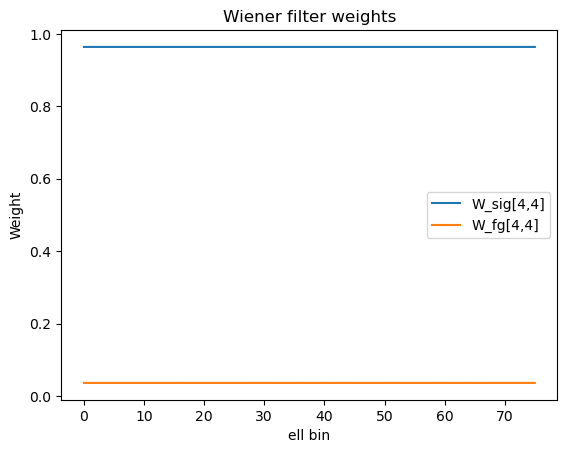

In [32]:
W_sig = np.zeros((n_bins, nfreqs, nfreqs))
W_fg = np.zeros((n_bins, nfreqs, nfreqs))
for b in range(n_bins):
    Cinv = np.linalg.inv(c_hat[b])  # safe now that c_hat is regularized (bounded condition number)
    W_sig[b] = C_HI_noise_hat[b] @ Cinv
    W_fg[b] = C_FG_pca[b] @ Cinv

plt.plot(W_sig[:, f, f], label=f"W_sig[{f},{f}]")
plt.plot(W_fg[:, f, f], label=f"W_fg[{f},{f}]")
plt.xlabel("ell bin")
plt.ylabel("Weight")
plt.title("Wiener filter weights")
plt.legend()
plt.show()

## Apply the per-bin Wiener filter to the observed-data alms and reconstruct maps

In [33]:
b_nmt = nmt.NmtBin.from_lmax_linear(lmax, nlb=bin_width)

alm_sig = np.zeros_like(sky_alm)
alm_fg = np.zeros_like(sky_alm)

for b in range(n_bins):
    for l in b_nmt.get_ell_list(b):
        idx = hp.Alm.getidx(lmax, l, np.arange(l + 1))
        alm_sig[:, idx] = W_sig[b] @ sky_alm[:, idx]
        alm_fg[:, idx] = W_fg[b] @ sky_alm[:, idx]

# NmtBin.from_lmax_linear only bins up through its last full bin -- reuse the last bin's filter
# for the remaining multipoles up to lmax instead of leaving them at zero.
last_covered_ell = b_nmt.get_ell_list(n_bins - 1)[-1]
for l in range(last_covered_ell + 1, lmax + 1):
    idx = hp.Alm.getidx(lmax, l, np.arange(l + 1))
    alm_sig[:, idx] = W_sig[n_bins - 1] @ sky_alm[:, idx]
    alm_fg[:, idx] = W_fg[n_bins - 1] @ sky_alm[:, idx]

In [34]:
sig_recovered = np.zeros((nfreqs, npix))
fg_recovered = np.zeros((nfreqs, npix))
for nf in range(nfreqs):
    sig_recovered[nf] = hp.alm2map(alm_sig[nf], nside, lmax=lmax)
    fg_recovered[nf] = hp.alm2map(alm_fg[nf], nside, lmax=lmax)

patch = mask.astype(bool)
hi_noise_truth = hi_masked + noise_masked
print(f"HI+noise recovered std (patch) = {np.std(sig_recovered[:, patch]):.4g} mK")
print(f"HI+noise truth std (patch)     = {np.std(hi_noise_truth[:, patch]):.4g} mK")
print("---------------------------")
print(f"FG recovered std (patch) = {np.std(fg_recovered[:, patch]):.4g} mK")
print(f"FG truth std (patch)     = {np.std(fgds_masked[:, patch]):.4g} mK")

HI+noise recovered std (patch) = 0.0934 mK
HI+noise truth std (patch)     = 0.09282 mK
---------------------------
FG recovered std (patch) = 216.7 mK
FG truth std (patch)     = 225.4 mK


In [35]:
# np.save(f"{input_path}/UHF/hi_noise_PCA.npy", sig_recovered)
# np.save(f"{input_path}/UHF/fg_PCA.npy", fg_recovered)

## Plots

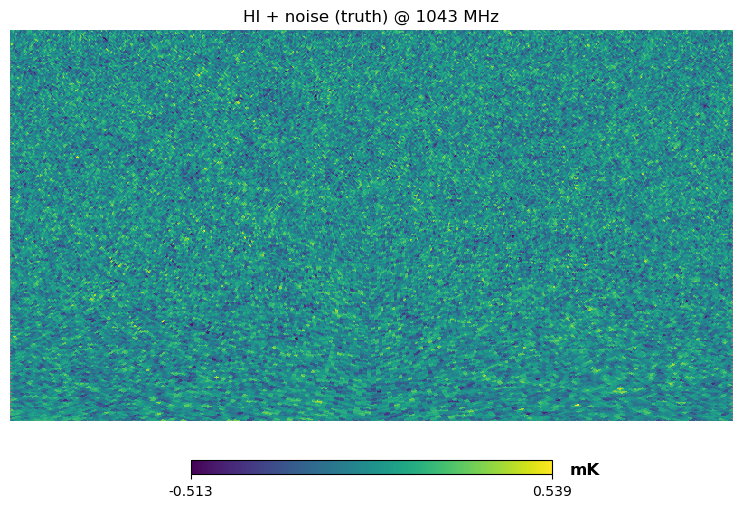

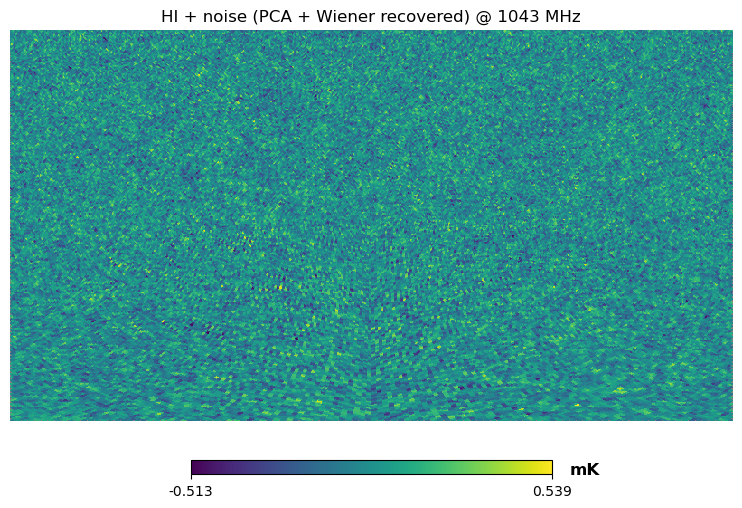

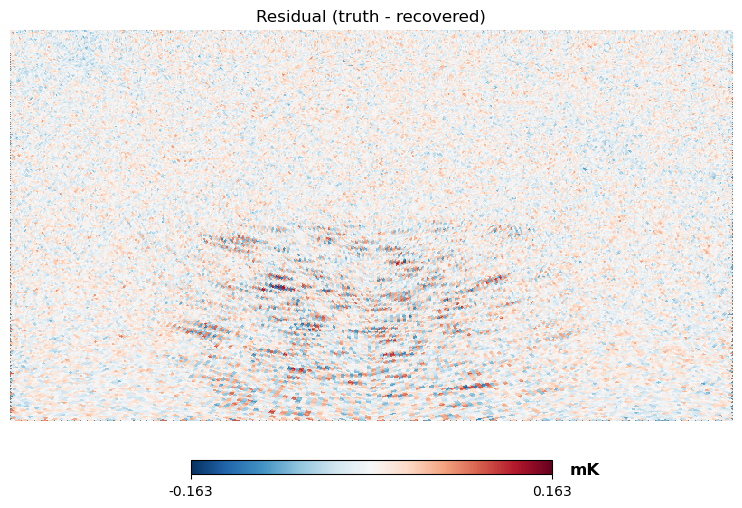

In [49]:
f=1
hi_noise_truth_nan = apply_mask_with_nan(hi_noise_truth[f], mask)
sig_recovered_nan = apply_mask_with_nan(sig_recovered[f], mask)
vmin, vmax = np.nanmin(hi_noise_truth_nan), np.nanmax(hi_noise_truth_nan)

hp.cartview(hi_noise_truth_nan, lonra=lonra, latra=latra, title=f"HI + noise (truth) @ {freqs[f]} MHz",
            unit="mK", min=vmin, max=vmax)
hp.cartview(sig_recovered_nan, lonra=lonra, latra=latra, title=f"HI + noise (PCA + Wiener recovered) @ {freqs[f]} MHz",
            unit="mK", min=vmin, max=vmax)

residual = hi_noise_truth_nan - sig_recovered_nan
vabs = np.nanmax(np.abs(residual))
hp.cartview(residual, lonra=lonra, latra=latra, title="Residual (truth - recovered)",
            unit="mK", cmap='RdBu_r', min=-vabs, max=vabs)

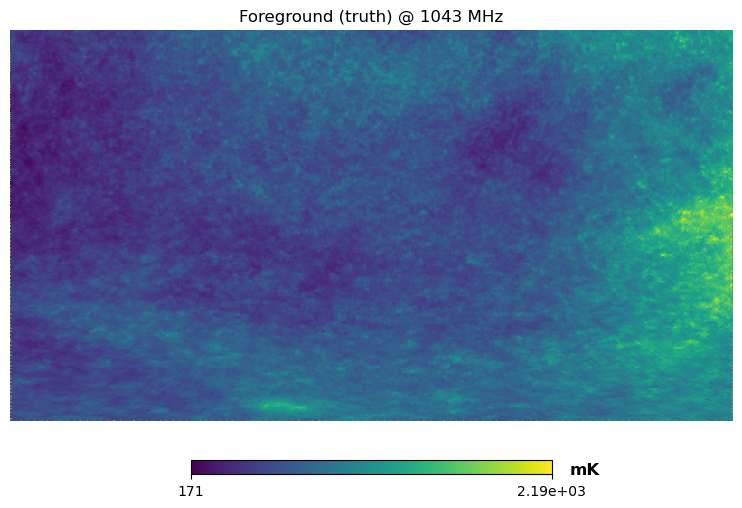

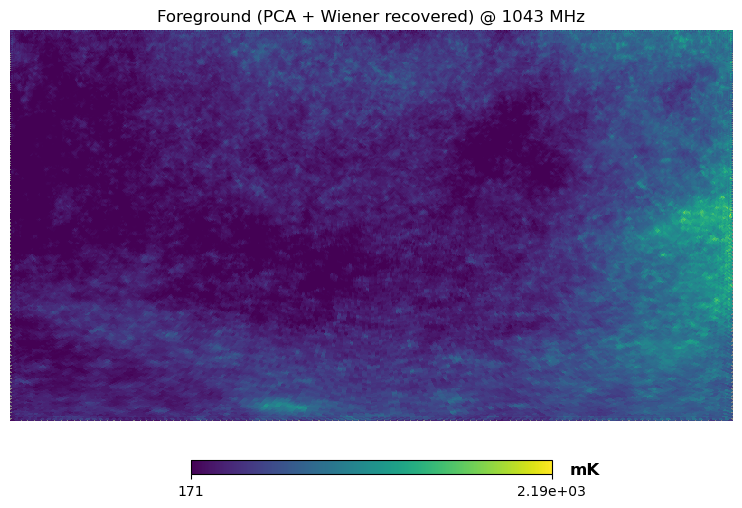

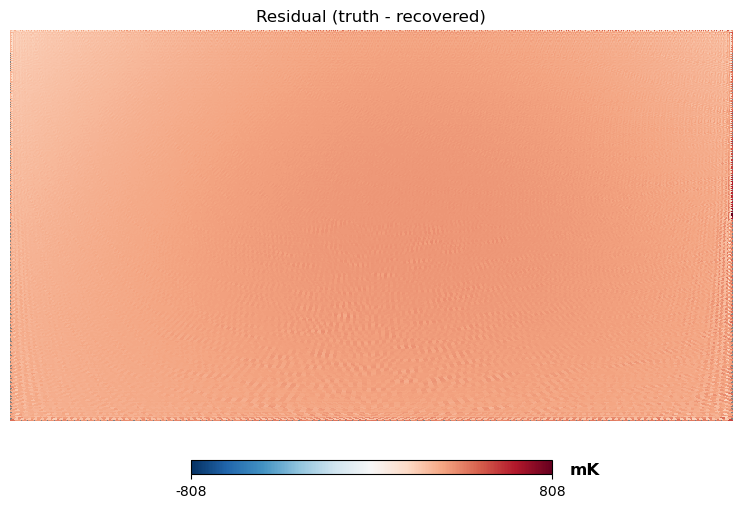

In [50]:
fgds_masked_nan = apply_mask_with_nan(fgds_masked[f], mask)
fg_recovered_nan = apply_mask_with_nan(fg_recovered[f], mask)
vmin, vmax = np.nanmin(fgds_masked_nan), np.nanmax(fgds_masked_nan)

hp.cartview(fgds_masked_nan, lonra=lonra, latra=latra, title=f"Foreground (truth) @ {freqs[f]} MHz",
            unit="mK", min=vmin, max=vmax)
hp.cartview(fg_recovered_nan, lonra=lonra, latra=latra, title=f"Foreground (PCA + Wiener recovered) @ {freqs[f]} MHz",
            unit="mK", min=vmin, max=vmax)

residual_fg = fgds_masked_nan - fg_recovered_nan
vabs = np.nanmax(np.abs(residual_fg))
hp.cartview(residual_fg, lonra=lonra, latra=latra, title="Residual (truth - recovered)",
            unit="mK", cmap='RdBu_r', min=-vabs, max=vabs)

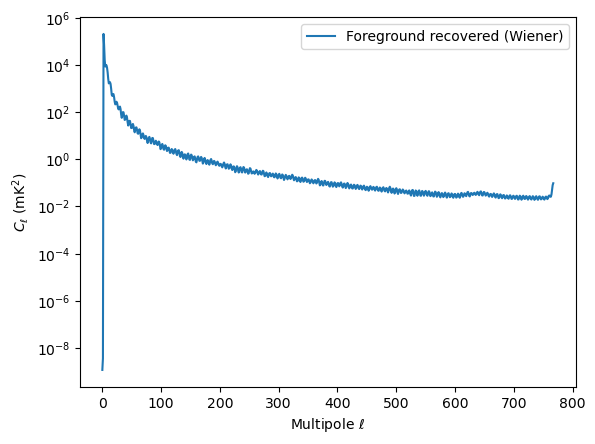

In [48]:
sig_w = hp.anafast(sig_recovered[f])
fg_w = hp.anafast(fg_recovered[f])

# plt.plot(leff, hi_noise_binned[:, f, f], 'k--', alpha=0.6, label='HI+noise truth')
# plt.plot(sig_w/fsky, label='HI+noise recovered (Wiener)')
# plt.plot(leff, fgds_binned[:, f, f], alpha=0.6, label='Foreground truth')
plt.plot(fg_w/fsky, label='Foreground recovered (Wiener)')
plt.yscale('log')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$C_\ell$ (mK$^2$)')
plt.legend()
plt.show()